# class 1


In [96]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import random

In [4]:
data = sns.load_dataset("iris")
data

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


# Question 1
- for each column including categorical columns find descriptive statistics
- for each Numerical column 20% 40% 60% 80% quantile
- prepare a box plot for each numerical column

In [6]:
data.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [11]:
data.describe(include=[int,float,object])

,sepal_length,sepal_width,petal_length,petal_width,species
count,150.000000,150.000000,150.000000,150.000000,150
unique,NaN,NaN,NaN,NaN,3
top,NaN,NaN,NaN,NaN,setosa
freq,NaN,NaN,NaN,NaN,50
mean,5.843333,3.057333,3.758000,1.199333,NaN
std,0.828066,0.435866,1.765298,0.762238,NaN
min,4.300000,2.000000,1.000000,0.100000,NaN
25%,5.100000,2.800000,1.600000,0.300000,NaN
50%,5.800000,3.000000,4.350000,1.300000,NaN
75%,6.400000,3.300000,5.100000,1.800000,NaN


In [39]:
data.select_dtypes(include="number")

data.iloc[ : , : -1]

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [69]:
data.quantile(q=0.20, numeric_only=True)
data.quantile(q=0.40, numeric_only=True)
data.quantile(q=0.60, numeric_only=True)
data.quantile(q=0.80, numeric_only=True)

# type(data.quantile(q=0.20, numeric_only=True))

# qa = data.quantile(q=0.20, numeric_only=True)
# qa.name = '20%quantile'

# qb = data.quantile(q=0.40, numeric_only=True)
# qb.name = '40%quantile'

# qc = data.quantile(q=0.60, numeric_only=True)

# qd = data.quantile(q=0.80, numeric_only=True)

# type(data.quantile(q=0.20, numeric_only=True))
# data.quantile(q=0.20, numeric_only=True).name



dictOfData = {
    'quantile20percent': data.quantile(q=0.20, numeric_only=True),
    'quantile40percent': data.quantile(q=0.20, numeric_only=True),
    'quantile60percent': data.quantile(q=0.20, numeric_only=True),
    'quantile80percent': data.quantile(q=0.20, numeric_only=True)

}

df = pd.DataFrame(dictOfData)

df.stack().unstack(0)


,sepal_length,sepal_width,petal_length,petal_width
quantile20percent,5.0,2.7,1.5,0.2
quantile40percent,5.0,2.7,1.5,0.2
quantile60percent,5.0,2.7,1.5,0.2
quantile80percent,5.0,2.7,1.5,0.2


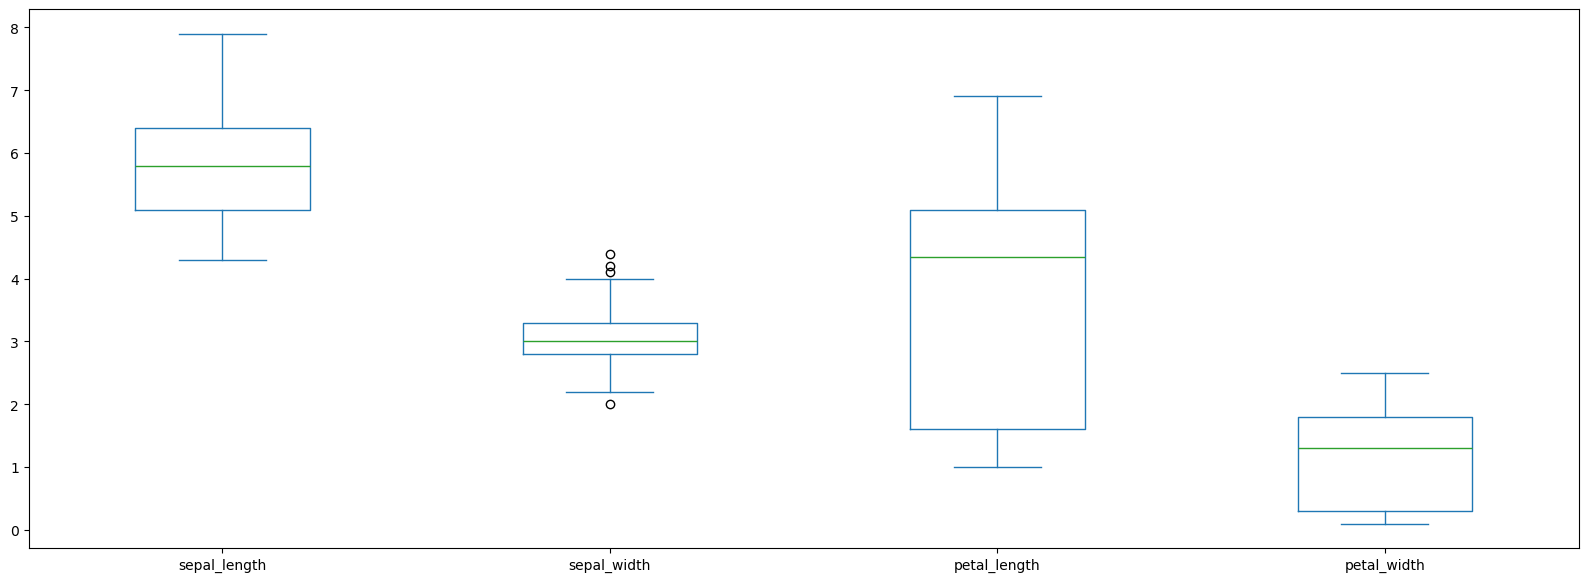

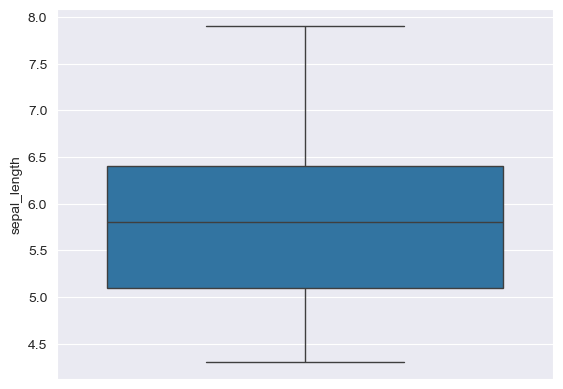

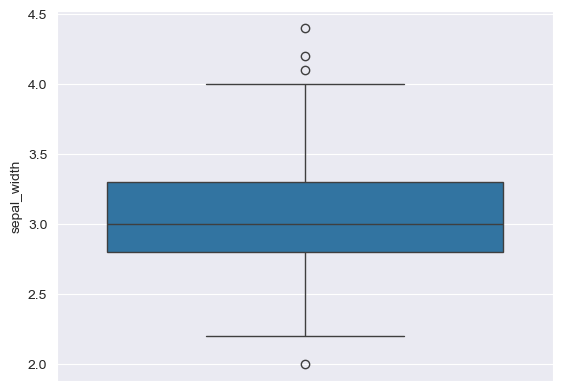

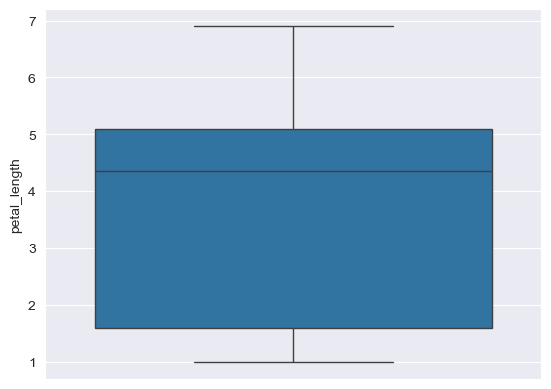

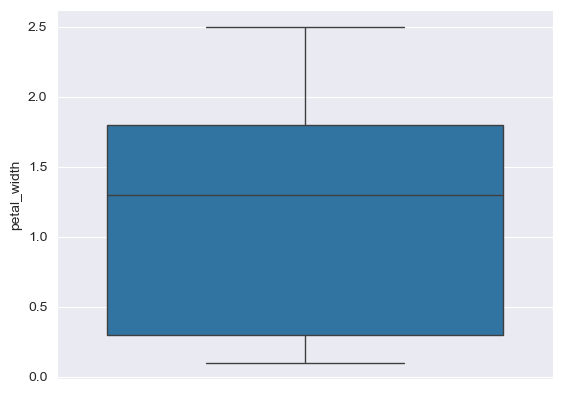

In [44]:
# sns.boxplot(data=data, y='sepal_length')
# plt.show()

# sns.boxplot(data=data, y='sepal_width')
# plt.show()

# sns.boxplot(data=data, y='petal_length')
# plt.show()

# sns.boxplot(data=data, y='petal_width')
# plt.show()

data.plot(kind="box", figsize =(20,7))
plt.show()

sns.set_style("darkgrid")
for col in data.iloc[:,:-1].columns:
    sns.boxplot(data[col])
    plt.show()


# histogram
- q4 for each column we want to produce histogram

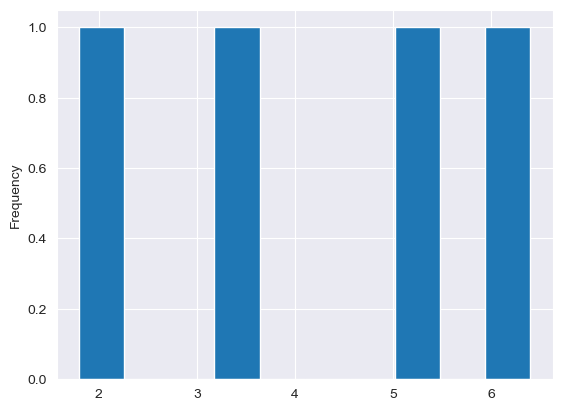

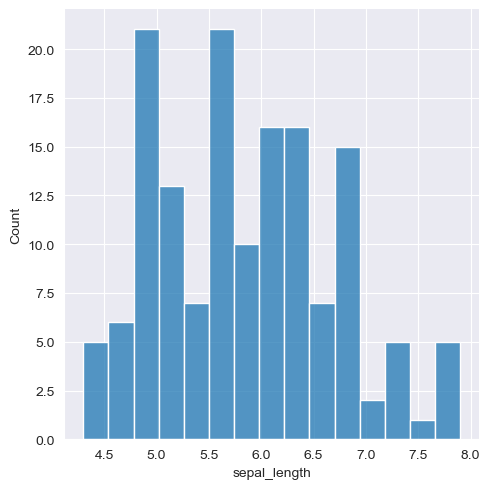

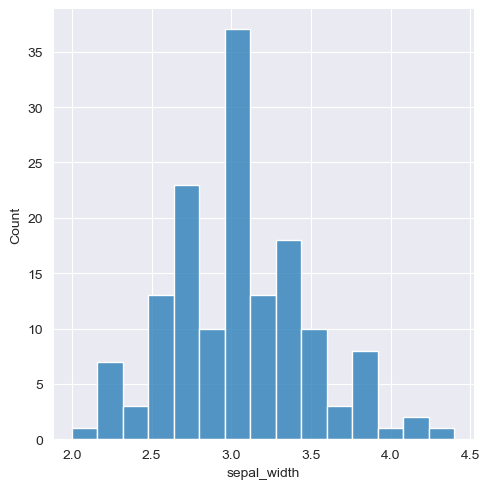

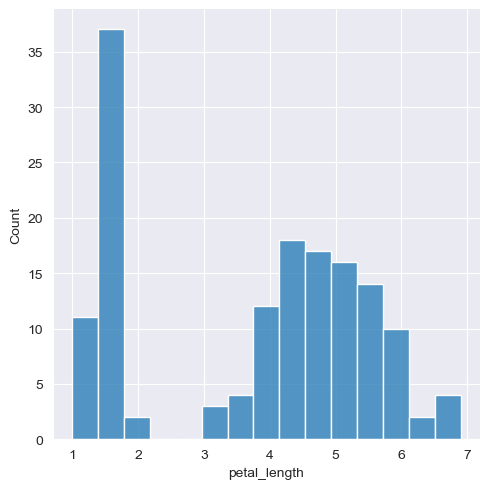

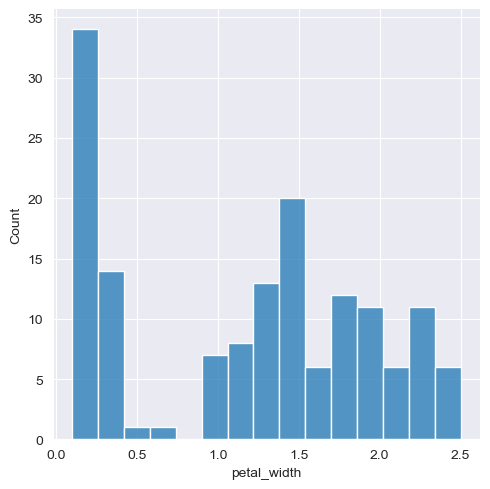

In [55]:
data.iloc[:,:-1].quantile(q=.75).plot(kind='hist')
plt.show()

data.iloc[:,:-1].quantile(q=.75)



for col in data.iloc[:,:-1].columns:
    sns.displot(data[col], bins=15)
    plt.show()

# skewness


In [ ]:
# bowleys coefficient
q1 = data.iloc[:,:-1].quantile(q=.25)
q2 = data.iloc[:,:-1].quantile(q=.5)
q3 = data.iloc[:,:-1].quantile(q=.75)

sb = (q3 - (2* q2) + q1)/(q3-q1)
print(sb)


# karls coefficient

mean = data.select_dtypes("number").mean()
median = data.select_dtypes("number").median()
variance = data.select_dtypes("number").var()
arr = []
for i in variance:
    arr.append(math.sqrt(i))
standardDeviation = pd.Series(arr)

sk = (3 * (mean - median))/standardDeviation


sepal_length   -0.076923
sepal_width     0.200000
petal_length   -0.571429
petal_width    -0.333333
dtype: float64


In [76]:
data.select_dtypes("number").mean()

sepal_length    5.843333
sepal_width     3.057333
petal_length    3.758000
petal_width     1.199333
dtype: float64

In [85]:
def kp_coef(data):
    mean = data.mean()
    median = data.median()
    std = data.std()
    return 3*(mean - median)/std

In [87]:
def karl_coef(data):
    q1, q2, q3 = np.quantile(data, [0.25, 0.50, 0.75])
    return (q3-(2*q2)+q1)/(q3-q1)

In [94]:
print("bowleys coefficients")
for col in data.select_dtypes("number").columns:
    dat = data[col]
    print(kp_coef(dat))

print("\nkarls coefficients")
for col in data.select_dtypes("number").columns:
    dat = data[col]
    print(karl_coef(dat))


bowleys coefficients
0.1569922927743242
0.394616436150782
-1.0060622995813977
-0.3962018833468465

karls coefficients
-0.07692307692307661
0.1999999999999993
-0.5714285714285714
-0.3333333333333333


In [119]:
totalCnt = 0
resCnt = 0

for i in range(1000000):
    a = math.floor(random.random() * 10)
    b = math.floor(random.random() * 10)
    if(a==0 or b==0 or a>6 or b>6):
        continue

    totalCnt+=1
    if a+b==7:
        resCnt+=1


resCnt/totalCnt


0.16604728460118753

In [111]:
random.random()

0.9818833953551025

In [112]:
1/6

0.16666666666666666

In [123]:
a = np.random.choice([1,2,3,4,5,6],1)

In [124]:
a[0]

6

In [125]:
cnt = 0
for i in range(1000000):
    if np.random.choice([1,2,3,4,5,6],1)[0] + np.random.choice([1,2,3,4,5,6],1)[0] == 7:
        cnt +=1

cnt/1000000

0.166306

In [132]:
totalCnt = 0
resCnt = 0

for i in range(10000000):
    a = random.random() <= 1/2
    b = random.random() <= 2/3
    c = random.random() <= 3/4


    totalCnt+=1

    if (a and not b and not c) or (not a and b and not c) or (not a and not b and c):
        resCnt+=1


resCnt/totalCnt

0.2498478

In [129]:
1/4

0.25

In [ ]:
cnt = 10000000
totalMoney = 0


for i in range(cnt):
    a = random.random() <= 0.1
    b = random.random() <= 0.8
    if a:
        totalMoney+=1
    if b:
        totalMoney+=1

totalMoney/cnt

0.8998787

In [137]:
totalMoney

0